In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from statsforecast import StatsForecast
from statsforecast.models import CrostonOptimized


Bad value in file WindowsPath('C:/Users/dell/.matplotlib/stylelib/my_style.mplstyle'), line 8 ('axes.facecolor: #FFFFFF'): Key axes.facecolor: '' does not look like a color arg


In [2]:
monthly = pd.read_csv("../data/processed/monthly_with_pattern.csv", parse_dates=["Date"])
sample_ids = pd.read_csv("../data/processed/sample_ids.csv")

#Pattern labeling only becomes meaningful after aggregating records into store–item monthly time series.


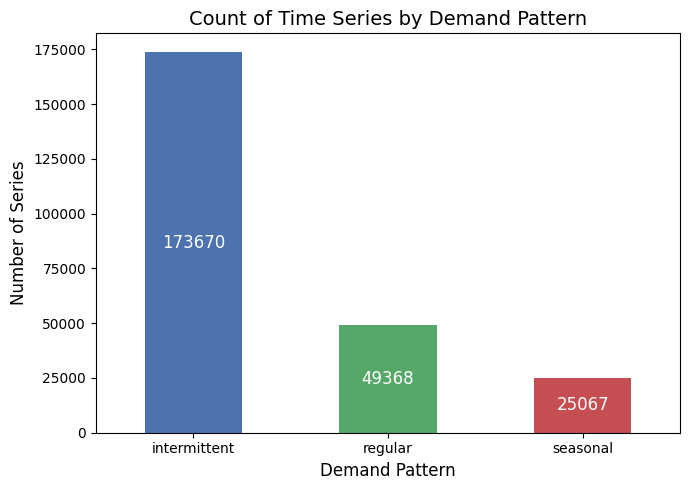

In [3]:
#df = pd.read_csv("../data/processed/series_pattern_summary.csv")

plt.figure(figsize=(7,5))

ax = monthly['pattern_label'].value_counts().plot(
    kind='bar',
    color=['#4C72B0', '#55A868', '#C44E52']
)

plt.title("Count of Time Series by Demand Pattern", fontsize=14)
plt.xlabel("Demand Pattern", fontsize=12)
plt.ylabel("Number of Series", fontsize=12)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12, label_type='center', color='white')

plt.tight_layout()

plt.savefig(f"../docs/p1/pattern_counts.png", dpi=300, bbox_inches='tight')
plt.show()


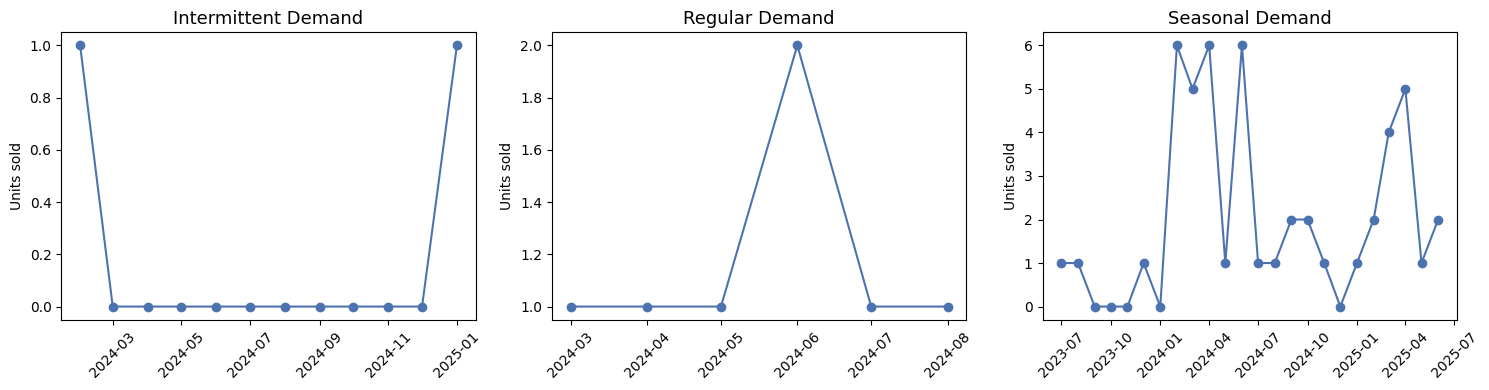

In [4]:
monthly["Date"] = pd.to_datetime(monthly["Date"])


# ======================================
# Select one example series per pattern (first) 
# ======================================
patterns = ["intermittent", "regular", "seasonal"]
examples = {}

for p in patterns:
    # Filter all rows for this pattern
    subset = monthly[monthly["pattern_label"] == p]
    
    if len(subset) == 0:
        print(f"⚠ No series found for pattern '{p}'")
        continue

    # Pick the first StoreId–ItemId combination
    series_key = subset.groupby(["StoreId", "ItemId"]).size().reset_index().iloc[0]
    sid = series_key["StoreId"]
    iid = series_key["ItemId"]

    # Extract the full time series for that pair
    ts = monthly[(monthly["StoreId"] == sid) &
                 (monthly["ItemId"] == iid)].sort_values("Date")

    examples[p] = ts


# ======================================
# Plotting 3 panels: intermittent, regular, seasonal
# ======================================
plt.figure(figsize=(15, 4))

for i, p in enumerate(patterns):
    if p not in examples:
        continue

    ts = examples[p]

    plt.subplot(1, 3, i + 1)
    plt.plot(ts["Date"], ts["units"], marker="o", color="#4C72B0")
    plt.title(f"{p.capitalize()} Demand", fontsize=13)
    plt.xlabel("")
    plt.ylabel("Units sold")
    plt.xticks(rotation=45)

plt.tight_layout()


plt.savefig(f"../docs/p1/representative_series.png", dpi=300)
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_19856\1521666383.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  series_metrics = monthly.groupby(["StoreId", "ItemId"]).apply(compute_metrics).reset_index()


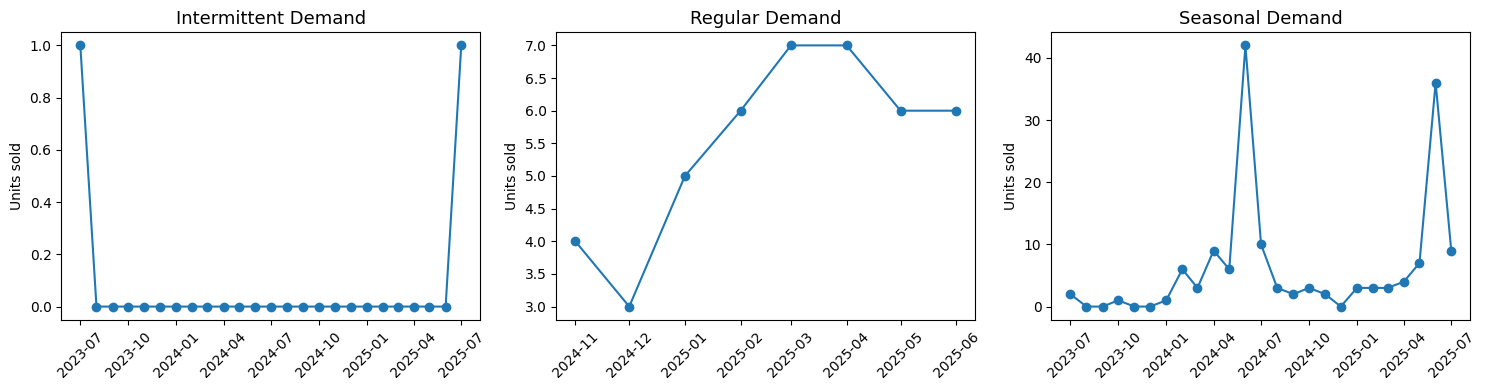

In [5]:
# ===============================
# Compute metrics for each series
# ===============================
def compute_metrics(group):
    y = group["units"].values
    zero_share = (y == 0).mean()
    mean_units = y.mean()
    std_units = y.std()
    cv_units = std_units / mean_units if mean_units > 0 else np.nan
    
    # ADI
    nz = np.where(y > 0)[0]
    ADI = np.diff(nz).mean() if len(nz) > 1 else np.nan
    
    # ACF12
    if len(y) >= 13:
        try:
            from statsmodels.tsa.stattools import acf
            acf12 = acf(y, nlags=12, fft=True)[12]
        except:
            acf12 = np.nan
    else:
        acf12 = np.nan

    # Seasonal Strength
    if len(y) >= 24:
        try:
            from statsmodels.tsa.seasonal import STL
            stl = STL(y, period=12).fit()
            ss = 1 - np.var(stl.resid) / np.var(stl.resid + stl.seasonal)
        except:
            ss = np.nan
    else:
        ss = np.nan

    return pd.Series({
        "zero_share": zero_share,
        "cv_units": cv_units,
        "ADI": ADI,
        "ACF12": acf12,
        "seasonal_strength": ss
    })

series_metrics = monthly.groupby(["StoreId", "ItemId"]).apply(compute_metrics).reset_index()

# Attach pattern labels
pattern_map = monthly.groupby(["StoreId", "ItemId"])["pattern_label"].first().reset_index()
series_metrics = series_metrics.merge(pattern_map, on=["StoreId","ItemId"], how="left")

# ===============================
# Select MOST TYPICAL representative series
# ===============================

# Typical intermittent = high zero_share, median-ish ADI
intermittent_df = series_metrics[series_metrics["pattern_label"]=="intermittent"].copy()
intermittent_df = intermittent_df.sort_values(["zero_share","ADI"], ascending=[False, True])
rep_inter = intermittent_df.iloc[0]

# Typical regular = lowest CV, lowest zero-share
regular_df = series_metrics[series_metrics["pattern_label"]=="regular"].copy()
regular_df = regular_df.sort_values(["cv_units","zero_share"], ascending=[True, True])
rep_reg = regular_df.iloc[0]

# Typical seasonal = highest seasonal_strength (or ACF12)
seasonal_df = series_metrics[series_metrics["pattern_label"]=="seasonal"].copy()
seasonal_df["season_rank"] = seasonal_df[["seasonal_strength","ACF12"]].mean(axis=1)
seasonal_df = seasonal_df.sort_values("season_rank", ascending=False)
rep_sea = seasonal_df.iloc[0]

# ===============================
# Extract time series
# ===============================
def extract_ts(row):
    sid, iid = row["StoreId"], row["ItemId"]
    ts = monthly[(monthly["StoreId"]==sid)&(monthly["ItemId"]==iid)]
    return ts.sort_values("Date")

ts_inter = extract_ts(rep_inter)
ts_reg = extract_ts(rep_reg)
ts_sea = extract_ts(rep_sea)

# ===============================
# Final 3-panel plot
# ===============================
plt.figure(figsize=(15,4))

series_list = [("Intermittent", ts_inter), ("Regular", ts_reg), ("Seasonal", ts_sea)]

for i, (title, ts) in enumerate(series_list):
    plt.subplot(1,3,i+1)
    plt.plot(ts["Date"], ts["units"], marker='o')
    plt.title(f"{title} Demand", fontsize=13)
    plt.ylabel("Units sold")
    plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(f"../docs/p1/representative_series_typical.png", dpi=300)
plt.show()


In [6]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not mask.any():
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if not mask.any():
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def bias(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_pred - y_true)

def mase(y_true, y_pred, train):
    train = np.asarray(train)
    naive_errors = np.abs(train[1:] - train[:-1])
    denom = naive_errors.mean()
    if denom == 0:
        return mae(y_true, y_pred)
    return mae(y_true, y_pred) / denom


In [7]:
def evaluate_models(store, item, pattern, monthly_df=None):
    """
    Fit all candidate models for a given store–item series and return
    a list of metric dicts. If monthly_df is provided, use it; otherwise
    fall back to the global 'monthly'.
    """
    df = monthly if monthly_df is None else monthly_df

    grp = (df[(df["StoreId"] == store) &
              (df["ItemId"] == item)]
             .sort_values("Date"))
    y = grp["units"].to_numpy()
    dates = grp["Date"].to_numpy()

    if len(y) < 15:
        return []

    train, test = y[:-3], y[-3:]
    train_dates = dates[:-3]
    test_dates = dates[-3:]

    model_results = []

    def add_model_result(name, y_true, y_pred):
        model_results.append({
            "StoreId": store,
            "ItemId": item,
            "pattern_label": pattern,
            "model": name,
            "MAPE": mape(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "MAE": mae(y_true, y_pred),
            "sMAPE": smape(y_true, y_pred),
            "Bias": bias(y_true, y_pred),
            "MASE": mase(y_true, y_pred, train),
        })

    #Croston (only for intermittent)
    if pattern == "intermittent":
        try:
            df_train = pd.DataFrame({
                "unique_id": [f"{store}_{item}"] * len(train),
                "ds": train_dates,
                "y": train,
            })
            sf = StatsForecast(models=[CrostonOptimized()], freq="MS", n_jobs=1)
            fc = sf.forecast(df=df_train, h=3)
            preds = fc["CrostonOptimized"].to_numpy()
            add_model_result("Croston", test, preds)
        except Exception as e:
            print(f"Croston failed for {store}_{item}: {e}")

    #Exponential Smoothing (only if enough data)
    if len(train) >= 24:
        try:
            model_es = ExponentialSmoothing(train, seasonal="add", seasonal_periods=12)
            fit_es = model_es.fit(optimized=True)
            preds = fit_es.forecast(3)
            add_model_result("ExpSmoothing", test, preds)
        except Exception as e:
            print(f"ExpSmoothing failed for {store}_{item}: {e}")

    #SARIMA
    try:
        model_sa = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
        fit_sa = model_sa.fit(disp=False)
        preds = fit_sa.forecast(3)
        add_model_result("SARIMA", test, preds)
    except Exception as e:
        print(f"SARIMA failed for {store}_{item}: {e}")

    #Prophet (only for seasonal)
    if pattern == "seasonal":
        try:
            df_prophet = pd.DataFrame({"ds": train_dates, "y": train})
            m = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False
            )
            m.fit(df_prophet)
            future = pd.DataFrame({"ds": test_dates})
            forecast = m.predict(future)
            preds = forecast["yhat"].values
            add_model_result("Prophet", test, preds)
        except Exception as e:
            print(f"Prophet failed for {store}_{item}: {e}")

    #Machine Learning models
    try:
        df_feat = pd.DataFrame({"y": y})
        for lag in [1, 2, 3, 12]:
            df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)
        df_feat["month"] = grp["Date"].dt.month

        df_feat = df_feat.dropna()
        if len(df_feat) >= 5:
            X_full = df_feat.drop("y", axis=1).values
            y_full = df_feat["y"].values

            X_train, X_test = X_full[:-3], X_full[-3:]
            y_train, y_test = y_full[:-3], y_full[-3:]

            # MLR
            lr = LinearRegression().fit(X_train, y_train)
            preds_lr = lr.predict(X_test)
            add_model_result("MLR", y_test, preds_lr)

            # RF
            rf = RandomForestRegressor(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)
            preds_rf = rf.predict(X_test)
            add_model_result("RandomForest", y_test, preds_rf)

            # XGBoost
            xgb = XGBRegressor(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
            )
            xgb.fit(X_train, y_train)
            preds_xgb = xgb.predict(X_test)
            add_model_result("XGBoost", y_test, preds_xgb)
        else:
            print(f"ML skipped for {store}_{item}: too few samples")
    except Exception as e:
        print(f"ML features / models failed for {store}_{item}: {e}")

    return model_results


In [8]:
all_results = []
for _, row in sample_ids.iterrows():
    res = evaluate_models(row.StoreId, row.ItemId, row.pattern_label)
    all_results.extend(res)

results_df = pd.DataFrame(all_results)
results_df.head()



C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ML skipped for d9f7878a-927e-4d1f-96b4-20b5081eaa8e_dea1d2ab-2164-4247-b50b-14a87473a366: too few samples


C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ML skipped for 07614761-58a0-4db1-be64-f4630091d9b8_eb704803-8835-40a5-bd47-f5e4519d7f41: too few samples
SARIMA failed for 6ced3ba7-1352-40be-94fc-0b11d3182d8d_3289436a-4880-45c5-9c21-41894163f610: too many indices for array: array is 0-dimensional, but 1 were indexed
ML skipped for 6ced3ba7-1352-40be-94fc-0b11d3182d8d_3289436a-4880-45c5-9c21-41894163f610: too few samples
ML skipped for 5de6ad56-3364-48a4-aa65-3c3fec73f36f_eabaaf99-d080-4833-9910-9371f90e0cc7: too few samples


C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:58:10 - cmdstanpy - INFO - Chain [1] start processing
12:58:21 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


...

C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:58:22 - cmdstanpy - INFO - Chain [1] start processing
12:58:24 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ML skipped for bf923369-5d9d-443a-a368-f225eff052d2_f9c7a0d1-c07f-4d69-b189-8f15672c9cbd: too few samples


C:\Users\dell\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:58:24 - cmdstanpy - INFO - Chain [1] start processing
12:58:25 - cmdstanpy - INFO - Chain [1] done processing


ML skipped for 02a6faa8-5940-450f-9da1-29a78f806f05_eabaaf99-d080-4833-9910-9371f90e0cc7: too few samples


,StoreId,ItemId,pattern_label,model,MAPE,RMSE,MAE,sMAPE,Bias,MASE
0,d9f7878a-927e-4d1f-96b4-20b5081eaa8e,dea1d2ab-2164-4247-b50b-14a87473a366,intermittent,Croston,54.545054,0.516929,0.515150,116.666162,-0.212117,1.888884
1,d9f7878a-927e-4d1f-96b4-20b5081eaa8e,dea1d2ab-2164-4247-b50b-14a87473a366,intermittent,SARIMA,99.999975,0.957427,0.833333,155.555541,-0.833333,3.055555
2,07614761-58a0-4db1-be64-f4630091d9b8,eb704803-8835-40a5-bd47-f5e4519d7f41,intermittent,Croston,43.183416,0.526658,0.522722,151.691688,0.234833,0.550234
3,07614761-58a0-4db1-be64-f4630091d9b8,eb704803-8835-40a5-bd47-f5e4519d7f41,intermittent,SARIMA,61.265055,1.516721,1.304053,162.773191,0.286272,1.372688
4,5de6ad56-3364-48a4-aa65-3c3fec73f36f,eabaaf99-d080-4833-9910-9371f90e0cc7,regular,SARIMA,38.848141,0.481855,0.454229,48.426904,0.004806,0.349407


In [9]:
# Average performance by model and pattern
pattern_model_perf = (
    results_df
        .groupby(["pattern_label", "model"])
        [["MAPE", "RMSE", "MAE", "sMAPE", "Bias", "MASE"]]
        .mean()
        .reset_index()
)

pattern_model_perf


,pattern_label,model,MAPE,RMSE,MAE,sMAPE,Bias,MASE
0,intermittent,Croston,48.864235,0.521794,0.518936,134.178925,0.011358,1.219559
1,intermittent,SARIMA,80.632515,1.237074,1.068693,159.164366,-0.273531,2.214121
2,regular,SARIMA,38.848141,0.481855,0.454229,48.426904,0.004806,0.349407
3,seasonal,Prophet,148.904451,3.902198,3.344246,101.285155,-0.861241,2.549224
4,seasonal,SARIMA,86.126312,2.439394,2.128706,118.171089,-0.747673,1.525706


In [10]:
# Best model per pattern (MAPE as primary)
best_model_per_pattern = (
    pattern_model_perf
        .sort_values(["pattern_label", "MAPE"])
        .groupby("pattern_label")
        .first()
)

best_model_per_pattern


,model,MAPE,RMSE,MAE,sMAPE,Bias,MASE
pattern_label,,,,,,,
intermittent,Croston,48.864235,0.521794,0.518936,134.178925,0.011358,1.219559
regular,SARIMA,38.848141,0.481855,0.454229,48.426904,0.004806,0.349407
seasonal,SARIMA,86.126312,2.439394,2.128706,118.171089,-0.747673,1.525706


In [11]:
# Universal SARIMA performance (across all patterns)
sarima_overall = (
    results_df[results_df["model"] == "SARIMA"]
        [["MAPE", "RMSE", "MAE", "sMAPE", "Bias", "MASE"]]
        .mean()
)

# Pattern-specific routing performance:
# choose best model per pattern and average their results
pattern_best_avg = []
for pattern in results_df["pattern_label"].unique():
    # best model for this pattern based on MAPE
    best_model = (
        results_df[results_df["pattern_label"] == pattern]
            .groupby("model")["MAPE"]
            .mean()
            .idxmin()
    )
    # gather all metrics for this model-pattern combo
    subset = results_df[
        (results_df["pattern_label"] == pattern) &
        (results_df["model"] == best_model)
    ][["MAPE", "RMSE", "MAE", "sMAPE", "Bias", "MASE"]]
    
    pattern_best_avg.append(subset.mean())

pattern_specific_overall = sum(pattern_best_avg) / len(pattern_best_avg)

sarima_overall, pattern_specific_overall


(MAPE      76.415351
 RMSE       1.712364
 MAE        1.496289
 sMAPE    120.211484
 Bias      -0.464212
 MASE       1.559128
 dtype: float64,
 MAPE      57.946230
 RMSE       1.147681
 MAE        1.033957
 sMAPE    100.258972
 Bias      -0.243836
 MASE       1.031557
 dtype: float64)

In [12]:
improvement = (sarima_overall - pattern_specific_overall) / sarima_overall * 100
improvement


MAPE     24.169387
RMSE     32.976818
MAE      30.898563
sMAPE    16.597841
Bias     47.473076
MASE     33.837542
dtype: float64

In [13]:
summary_table = pd.DataFrame({
    "Universal SARIMA": sarima_overall.round(3),
    "Pattern-Specific Routing": pattern_specific_overall.round(3),
    "% Improvement": improvement.round(1)
})

summary_table


,Universal SARIMA,Pattern-Specific Routing,% Improvement
MAPE,76.415,57.946,24.2
RMSE,1.712,1.148,33.0
MAE,1.496,1.034,30.9
sMAPE,120.211,100.259,16.6
Bias,-0.464,-0.244,47.5
MASE,1.559,1.032,33.8


<Figure size 1000x600 with 0 Axes>

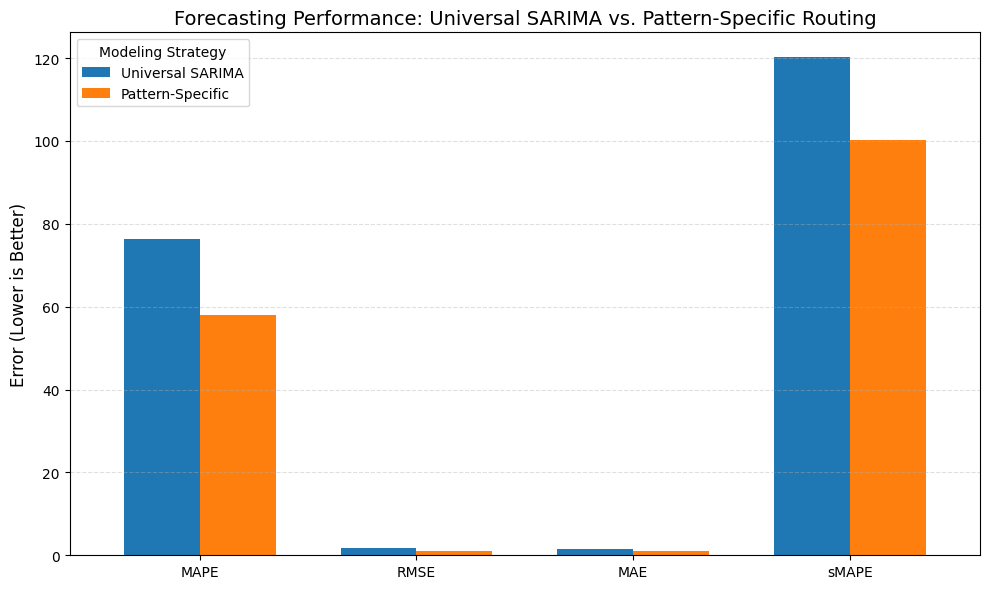

In [18]:


# ----------- 1. Compute universal SARIMA performance --------------
sarima_overall = (
    results_df[results_df["model"] == "SARIMA"]
        [["MAPE", "RMSE", "MAE", "sMAPE", "Bias", "MASE"]]
        .mean()
)

# ----------- 2. Compute pattern-specific routing performance -------
pattern_best_metrics = []

for pattern in results_df["pattern_label"].unique():
    subset = results_df[results_df["pattern_label"] == pattern]
    
    # find best model by lowest MAPE in that pattern
    best_model = (
        subset.groupby("model")["MAPE"].mean()
              .idxmin()
    )
    
    best_metrics = (
        subset[subset["model"] == best_model]
              [["MAPE", "RMSE", "MAE", "sMAPE", "Bias", "MASE"]]
              .mean()
    )
    
    pattern_best_metrics.append(best_metrics)

pattern_specific_overall = sum(pattern_best_metrics) / len(pattern_best_metrics)

# ----------- 3. Compute % improvement ------------------------------
improvement = (sarima_overall - pattern_specific_overall) / sarima_overall * 100

# ----------- 4. Build comparison dataframe ------------------------
df_plot = pd.DataFrame({
    "Universal SARIMA": sarima_overall,
    "Pattern-Specific": pattern_specific_overall,
    "% Improvement": improvement
}).round(2)

# Keep only the main four metrics for the poster
metrics_to_plot = ["MAPE", "RMSE", "MAE", "sMAPE"]
df_small = df_plot.loc[metrics_to_plot, ["Universal SARIMA", "Pattern-Specific"]]

# ----------- 5. Plot the bar chart --------------------------------
plt.figure(figsize=(10, 6))
df_small.plot(kind="bar", figsize=(10, 6), width=0.7)

plt.title("Forecasting Performance: Universal SARIMA vs. Pattern-Specific Routing",
          fontsize=14)
plt.ylabel("Error (Lower is Better)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Modeling Strategy")
plt.tight_layout()

# Save figure
plt.savefig("../docs/p1/pattern_specific_vs_universal.png", dpi=300)
plt.show()


In [14]:
metrics = ["MAPE", "RMSE", "MAE", "sMAPE", "Bias", "MASE"]

all_models = ["Croston", "ExpSmoothing", "SARIMA", "Prophet",
              "MLR", "RandomForest", "XGBoost"]
all_patterns = ["intermittent", "regular", "seasonal"]

summary_base = (
    results_df
    .groupby(["pattern_label", "model"])[metrics]
    .mean()
)

idx = pd.MultiIndex.from_product(
    [all_patterns, all_models],
    names=["pattern_label", "model"]
)

summary = (
    summary_base
    .reindex(idx)
    .reset_index()
    .sort_values(["pattern_label", "model"])
)

print(summary)
summary.to_csv("../data/processed/forecast_comparison_summary_all_metrics.csv", index=False)

   pattern_label         model        MAPE      RMSE       MAE       sMAPE  \
0   intermittent       Croston   48.864235  0.521794  0.518936  134.178925   
1   intermittent  ExpSmoothing         NaN       NaN       NaN         NaN   
4   intermittent           MLR         NaN       NaN       NaN         NaN   
3   intermittent       Prophet         NaN       NaN       NaN         NaN   
5   intermittent  RandomForest         NaN       NaN       NaN         NaN   
2   intermittent        SARIMA   80.632515  1.237074  1.068693  159.164366   
6   intermittent       XGBoost         NaN       NaN       NaN         NaN   
7        regular       Croston         NaN       NaN       NaN         NaN   
8        regular  ExpSmoothing         NaN       NaN       NaN         NaN   
11       regular           MLR         NaN       NaN       NaN         NaN   
10       regular       Prophet         NaN       NaN       NaN         NaN   
12       regular  RandomForest         NaN       NaN       NaN  

In [15]:
# Count how many times each model successfully produced forecasts
availability = (
    results_df
    .groupby(["pattern_label", "model"])
    .size()                              # count successful forecast runs
    .unstack("model", fill_value=0)      
)

# Reorder rows according to predefined pattern order
availability = availability.reindex(all_patterns)

# Ensure all model columns appear; any missing model is filled with zero
availability = availability.reindex(columns=all_models, fill_value=0)

print(availability)

model          Croston  ExpSmoothing  SARIMA  Prophet  MLR  RandomForest  \
pattern_label                                                              
intermittent         2             0       2        0    0             0   
regular              0             0       1        0    0             0   
seasonal             0             0       3        3    0             0   

model          XGBoost  
pattern_label           
intermittent         0  
regular              0  
seasonal             0  


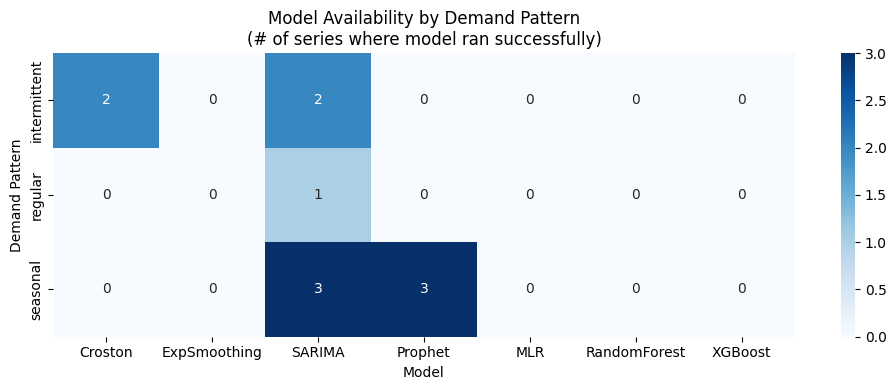

In [17]:
plt.figure(figsize=(10, 4))
sns.heatmap(
    availability,
    annot=True, fmt="d",
    cmap="Blues"
)
plt.title("Model Availability by Demand Pattern\n(# of series where model ran successfully)")
plt.xlabel("Model")
plt.ylabel("Demand Pattern")
plt.tight_layout()
#plt.savefig("../doc/p1/Figure_ModelAvailability.png", dpi=300, bbox_inches="tight")
plt.show()

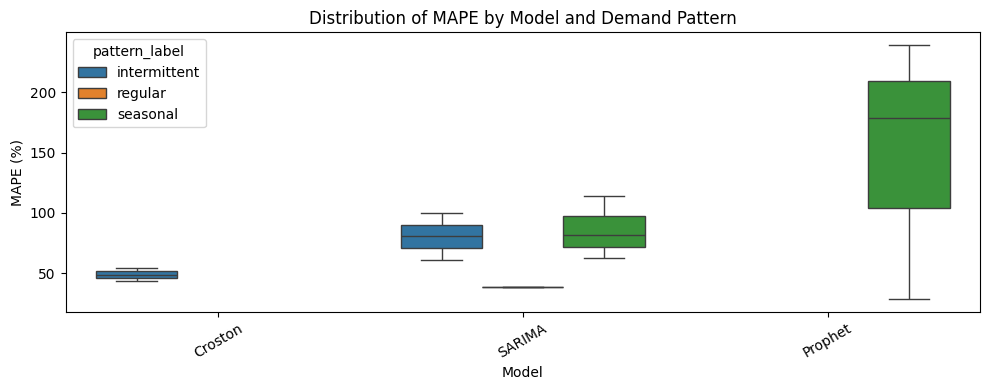

In [9]:
#Boxplot of MAPE per model within each demand type
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=results_df,
    x="model", y="MAPE", hue="pattern_label"
)
plt.title("Distribution of MAPE by Model and Demand Pattern")
plt.ylabel("MAPE (%)")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

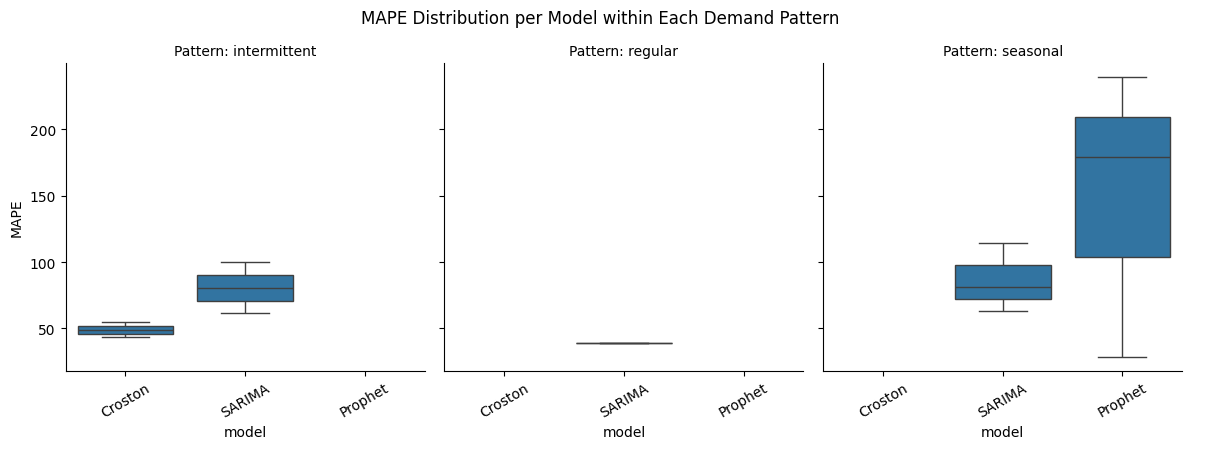

In [10]:
g = sns.catplot(
    data=results_df,
    x="model", y="MAPE",
    col="pattern_label",
    kind="box",
    height=4, aspect=1
)
g.set_titles("Pattern: {col_name}")
g.set_xticklabels(rotation=30)
g.fig.suptitle("MAPE Distribution per Model within Each Demand Pattern", y=1.05)
plt.show()

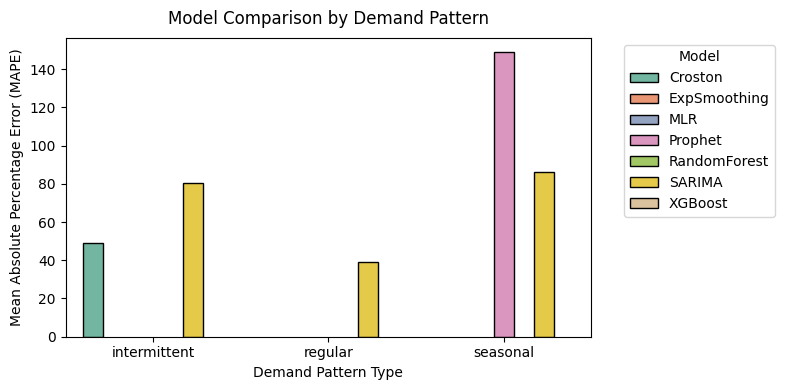

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=summary,
    x="pattern_label", y="MAPE", hue="model",
    palette="Set2", edgecolor="black"
)

plt.title("Model Comparison by Demand Pattern", fontsize=12, pad=10)
plt.ylabel("Mean Absolute Percentage Error (MAPE)")
plt.xlabel("Demand Pattern Type")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../doc/p1/Figure_ModelPerformance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Clean numeric formatting
summary_fmt = summary.copy()
summary_fmt["MAPE"] = summary_fmt["MAPE"].round(3)
summary_fmt["RMSE"] = summary_fmt["RMSE"].round(3)
summary_fmt["MAE"] = summary_fmt["MAE"].round(3)
summary_fmt["sMAPE"] = summary_fmt["sMAPE"].round(3)
summary_fmt["Bias"] = summary_fmt["Bias"].round(3)
summary_fmt["MASE"] = summary_fmt["MASE"].round(3)

# Save as CSV for later formatting in Word/LaTeX
summary_fmt.to_csv("../data/processed/Table_ModelPerformance.csv", index=False)

# Display top few rows nicely
print(summary_fmt.head(10))

   pattern_label         model    MAPE   RMSE    MAE    sMAPE   Bias   MASE
0   intermittent       Croston  48.864  0.522  0.519  134.179  0.011  1.220
1   intermittent  ExpSmoothing     NaN    NaN    NaN      NaN    NaN    NaN
4   intermittent           MLR     NaN    NaN    NaN      NaN    NaN    NaN
3   intermittent       Prophet     NaN    NaN    NaN      NaN    NaN    NaN
5   intermittent  RandomForest     NaN    NaN    NaN      NaN    NaN    NaN
2   intermittent        SARIMA  80.633  1.237  1.069  159.164 -0.274  2.214
6   intermittent       XGBoost     NaN    NaN    NaN      NaN    NaN    NaN
7        regular       Croston     NaN    NaN    NaN      NaN    NaN    NaN
8        regular  ExpSmoothing     NaN    NaN    NaN      NaN    NaN    NaN
11       regular           MLR     NaN    NaN    NaN      NaN    NaN    NaN


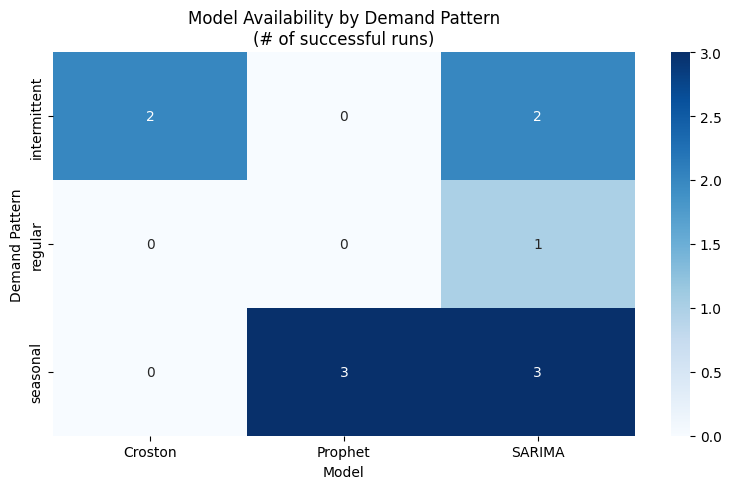

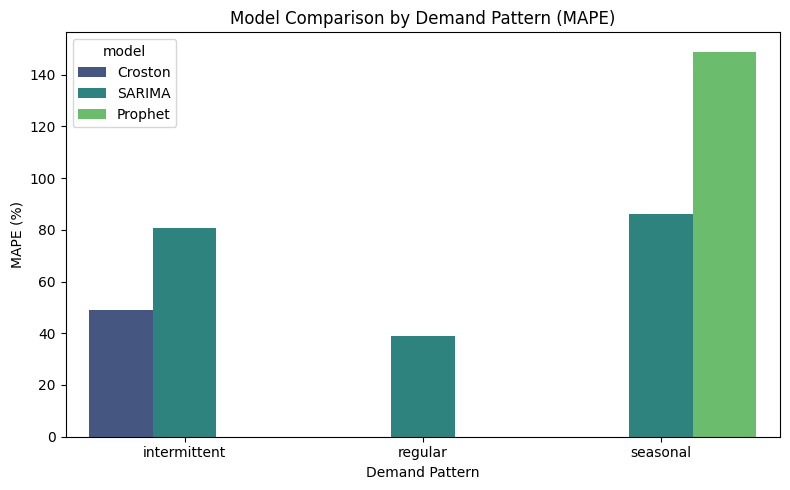

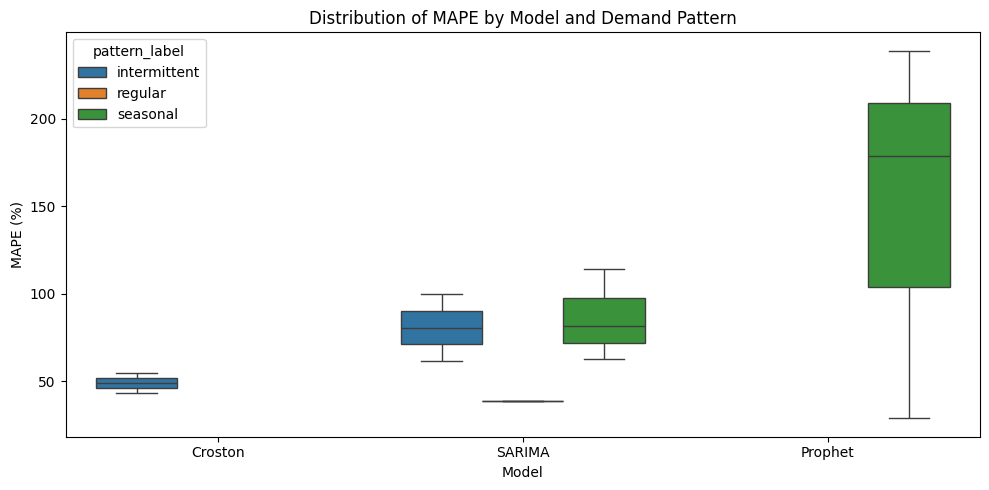

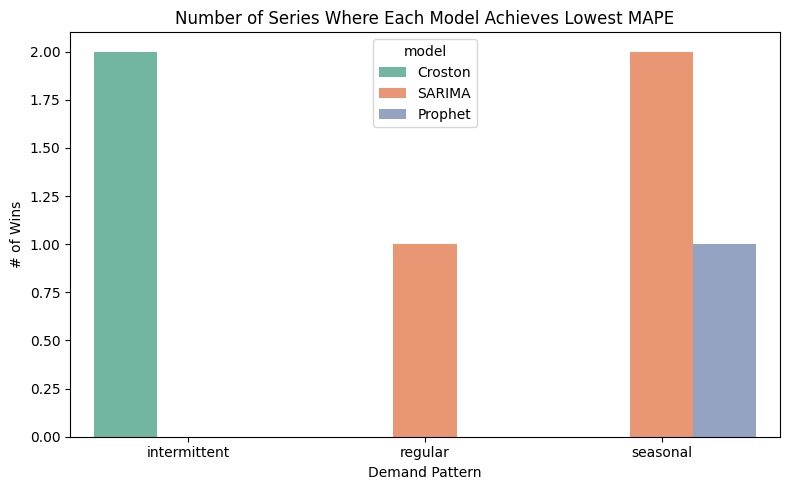

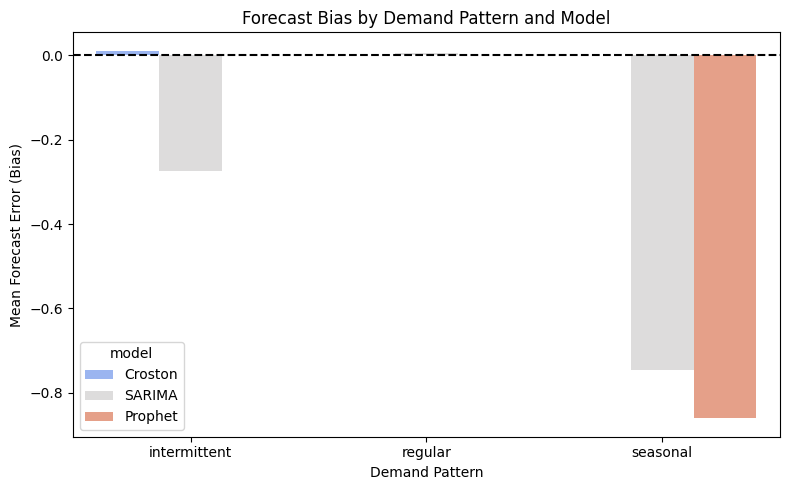

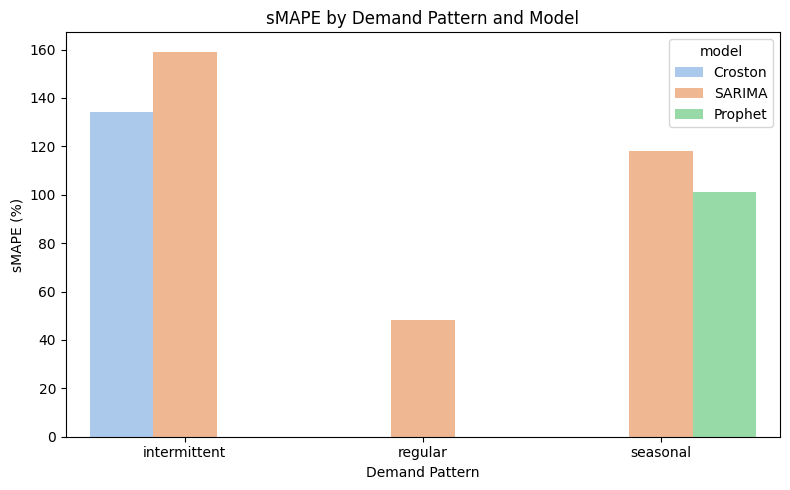

In [9]:

valid_models = {
    "intermittent": ["Croston", "SARIMA"],
    "regular": ["SARIMA"],
    "seasonal": ["SARIMA", "Prophet"]
}

results_clean = results_df[
    results_df.apply(lambda row: row.model in valid_models[row.pattern_label], axis=1)
].copy()

# =====================================================
# 1. MODEL AVAILABILITY HEATMAP
# =====================================================

avail = (
    results_clean.groupby(["pattern_label", "model"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(8, 5))
sns.heatmap(avail, annot=True, cmap="Blues", fmt="d")
plt.title("Model Availability by Demand Pattern\n(# of successful runs)")
plt.ylabel("Demand Pattern")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig("../docs/p1/model_availability_clean.png")
plt.show()

# =====================================================
# 2. MAPE BAR CHART
# =====================================================

mape_summary = (
    results_clean.groupby(["pattern_label", "model"])["MAPE"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=mape_summary,
    x="pattern_label",
    y="MAPE",
    hue="model",
    palette="viridis"
)
plt.title("Model Comparison by Demand Pattern (MAPE)")
plt.xlabel("Demand Pattern")
plt.ylabel("MAPE (%)")
plt.tight_layout()
plt.savefig("../docs/p1/mape_comparison_bar.png")
plt.show()

# =====================================================
# 3. MAPE BOXPLOT
# =====================================================

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=results_clean,
    x="model",
    y="MAPE",
    hue="pattern_label"
)
plt.title("Distribution of MAPE by Model and Demand Pattern")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.tight_layout()
plt.savefig("../docs/p1/mape_boxplot.png")
plt.show()

# =====================================================
# 4. WIN COUNT PLOT (LOWEST MAPE)
# =====================================================

winners = (
    results_clean.sort_values("MAPE")
    .groupby(["StoreId", "ItemId"])
    .first()
    .reset_index()
)

win_count = (
    winners.groupby(["pattern_label", "model"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=win_count,
    x="pattern_label",
    y="count",
    hue="model",
    palette="Set2"
)
plt.title("Number of Series Where Each Model Achieves Lowest MAPE")
plt.xlabel("Demand Pattern")
plt.ylabel("# of Wins")
plt.tight_layout()
plt.savefig("../docs/p1/win_count.png")
plt.show()

# =====================================================
# 5. BIAS BAR PLOT
# =====================================================

bias_summary = (
    results_clean.groupby(["pattern_label", "model"])["Bias"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=bias_summary,
    x="pattern_label",
    y="Bias",
    hue="model",
    palette="coolwarm"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Forecast Bias by Demand Pattern and Model")
plt.xlabel("Demand Pattern")
plt.ylabel("Mean Forecast Error (Bias)")
plt.tight_layout()
plt.savefig("../docs/p1/bias_comparison.png")
plt.show()

# =====================================================
# 6. sMAPE bar chart
# =====================================================

smape_summary = (
    results_clean.groupby(["pattern_label", "model"])["sMAPE"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=smape_summary,
    x="pattern_label",
    y="sMAPE",
    hue="model",
    palette="pastel"
)
plt.title("sMAPE by Demand Pattern and Model")
plt.xlabel("Demand Pattern")
plt.ylabel("sMAPE (%)")
plt.tight_layout()
plt.savefig("../docs/p1/smape_comparison.png")
plt.show()


In [13]:
#win count analysis
winners = (
    results_df
    .loc[results_df.groupby(["StoreId", "ItemId", "pattern_label"])["MAPE"].idxmin()]
    [["StoreId", "ItemId", "pattern_label", "model"]]
)

winners.head()

win_counts = (
    winners
    .groupby(["pattern_label", "model"])
    .size()
    .reset_index(name="n_wins")
    .sort_values(["pattern_label", "n_wins"], ascending=[True, False])
)

win_counts

,pattern_label,model,n_wins
0,intermittent,Croston,2
1,regular,SARIMA,1
3,seasonal,SARIMA,2
2,seasonal,Prophet,1


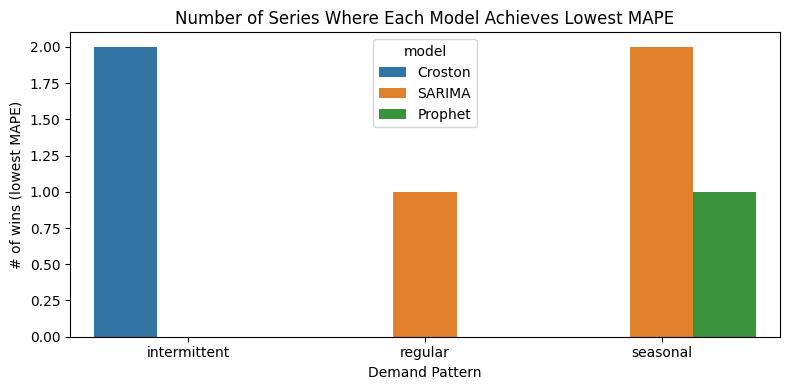

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=win_counts,
    x="pattern_label", y="n_wins", hue="model"
)
plt.title("Number of Series Where Each Model Achieves Lowest MAPE")
plt.ylabel("# of wins (lowest MAPE)")
plt.xlabel("Demand Pattern")
plt.tight_layout()
plt.show()


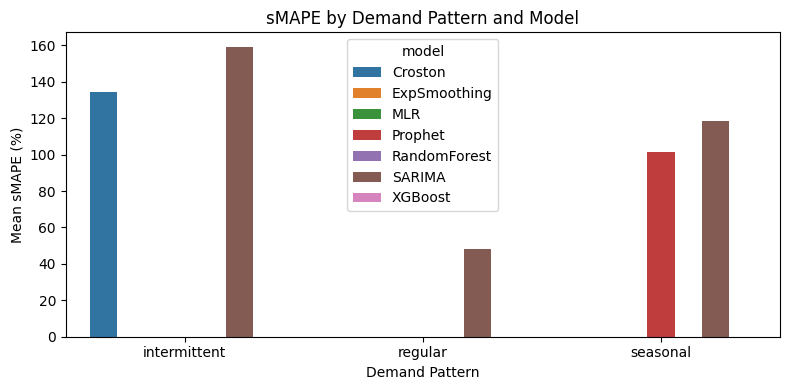

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=summary,
    x="pattern_label", y="sMAPE", hue="model"
)
plt.title("sMAPE by Demand Pattern and Model")
plt.ylabel("Mean sMAPE (%)")
plt.xlabel("Demand Pattern")
plt.tight_layout()
plt.show()

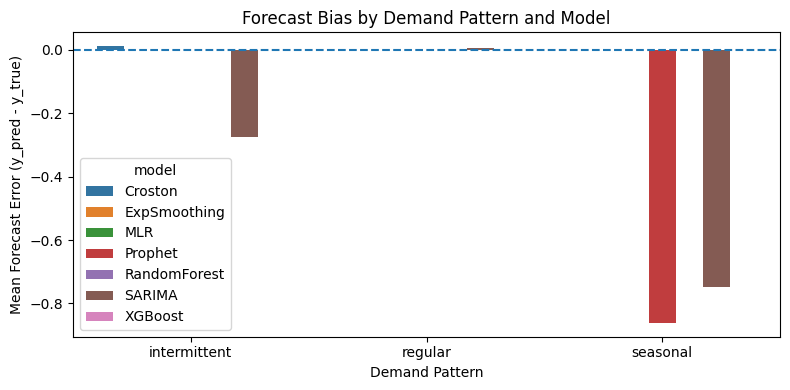

In [16]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=summary,
    x="pattern_label", y="Bias", hue="model"
)
plt.axhline(0, linestyle="--")
plt.title("Forecast Bias by Demand Pattern and Model")
plt.ylabel("Mean Forecast Error (y_pred - y_true)")
plt.xlabel("Demand Pattern")
plt.tight_layout()
plt.show()


Robustness Checks

In [22]:
metric_rankings = (
    summary
    .set_index(["pattern_label", "model"])[["MAPE","RMSE","MAE","sMAPE","MASE"]]
    .rank(method="min")  # lower is better
)

metric_rankings


MAPE  RMSE  MAE  sMAPE  MASE
pattern_label model                                     
intermittent  Croston        2.0   2.0  2.0    4.0   2.0
              ExpSmoothing   NaN   NaN  NaN    NaN   NaN
              MLR            NaN   NaN  NaN    NaN   NaN
              Prophet        NaN   NaN  NaN    NaN   NaN
              RandomForest   NaN   NaN  NaN    NaN   NaN
              SARIMA         3.0   3.0  3.0    5.0   4.0
              XGBoost        NaN   NaN  NaN    NaN   NaN
regular       Croston        NaN   NaN  NaN    NaN   NaN
              ExpSmoothing   NaN   NaN  NaN    NaN   NaN
              MLR            NaN   NaN  NaN    NaN   NaN
              Prophet        NaN   NaN  NaN    NaN   NaN
              RandomForest   NaN   NaN  NaN    NaN   NaN
              SARIMA         1.0   1.0  1.0    1.0   1.0
              XGBoost        NaN   NaN  NaN    NaN   NaN
seasonal      Croston        NaN   NaN  NaN    NaN   NaN
              ExpSmoothing   NaN   NaN  NaN    NaN   NaN
              MLR            NaN   NaN  NaN    NaN   NaN
              Prophet        5.0   5.0  5.0    2.0   5.0
              RandomForest   NaN   NaN  NaN    NaN   NaN
              SARIMA         4.0   4.0  4.0    3.0   3.0
              XGBoost        NaN   NaN  NaN    NaN   NaN

In [13]:
# to sampling
def bootstrap_model_performance(monthly_df, n_boot=30, n_per_pattern=3):
    """
    Bootstrap robustness check for model performance.

    monthly_df: DataFrame with columns StoreId, ItemId, pattern_label, Date, units
    n_boot: number of bootstrap replications
    n_per_pattern: number of series to sample per pattern in each replication
    """
    boot_results = []

    # unique series per pattern
    series_unique = (
        monthly_df[["StoreId", "ItemId", "pattern_label"]]
        .drop_duplicates()
        .dropna(subset=["pattern_label"])
    )

    def safe_sample(g, n):
        return g.sample(min(n, len(g)), replace=False, random_state=None)

    for b in range(n_boot):
        # 1) sample series in this replication
        sample_ids_b = (
            series_unique
            .groupby("pattern_label", group_keys=False)
            .apply(lambda g: safe_sample(g, n_per_pattern))
            .reset_index(drop=True)
        )

        # 2) evaluate models on these series
        all_results_b = []
        for _, row in sample_ids_b.iterrows():
            all_results_b.extend(
                evaluate_models(
                    row.StoreId,
                    row.ItemId,
                    row.pattern_label,
                    monthly_df=monthly_df
                )
            )

        df_b = pd.DataFrame(all_results_b)

        # 3) store mean MAPE per model for this replication
        boot_results.append(df_b.groupby("model")["MAPE"].mean())

    return pd.DataFrame(boot_results)


In [43]:
bootstrap_df = bootstrap_model_performance(monthly, n_boot=30)

bootstrap_df.boxplot(figsize=(10, 5))
plt.title("Bootstrap Stability of Model Performance (MAPE)")
plt.ylabel("MAPE")
plt.show()


ML skipped for e05b954a-caae-4fa7-a47d-8d02db5714a4_27dde2cf-93c9-4b0e-aa5e-da806584e283: too few samples
SARIMA failed for 51bca3f2-9ed2-43a9-b1c3-a95b35672a10_89dfbc8d-f16a-4176-ad0a-e490baacbcdd: too many indices for array: array is 0-dimensional, but 1 were indexed
ML skipped for 51bca3f2-9ed2-43a9-b1c3-a95b35672a10_89dfbc8d-f16a-4176-ad0a-e490baacbcdd: too few samples
ML skipped for 04145090-8478-4594-8599-b8bb8472f890_f9c7a0d1-c07f-4d69-b189-8f15672c9cbd: too few samples
ML skipped for 34ab215f-15e5-4b2a-b9a1-63d8074a7318_3289436a-4880-45c5-9c21-41894163f610: too few samples
ML skipped for e63f4731-0b08-4b11-928d-e94af2477088_21c6cbc3-7117-40f0-aa2d-103d74f24d89: too few samples


00:20:06 - cmdstanpy - INFO - Chain [1] start processing
00:20:06 - cmdstanpy - INFO - Chain [1] done processing


ML skipped for 6df8ccdc-f725-489f-9a72-660a32f391b8_ad9f7683-930b-49da-a5e1-60ec2a0f9831: too few samples


00:20:06 - cmdstanpy - INFO - Chain [1] start processing
00:20:15 - cmdstanpy - INFO - Chain [1] done processing


ML skipped for 051e8b35-89c4-4958-8b1d-3240ec71a037_8a7fa800-6ae2-4b64-ada5-f7bbf0bb7fcd: too few samples


...

ML skipped for 66ec0f30-8c61-4583-a634-a97336dc1bab_4f90622a-a55c-4047-a68c-05ac205518d3: too few samples


00:23:55 - cmdstanpy - INFO - Chain [1] start processing
00:24:06 - cmdstanpy - INFO - Chain [1] done processing


ML skipped for 629713c7-b7c1-4d01-a4f1-d036878384f9_8a7fa800-6ae2-4b64-ada5-f7bbf0bb7fcd: too few samples
ML skipped for 335a2b9b-b6ac-4543-a209-5fd31d7d43db_eb704803-8835-40a5-bd47-f5e4519d7f41: too few samples
ML skipped for 8ca317d9-3eb8-4a0b-83a5-0218b4c8ab70_3418a3c7-21d2-4529-840c-9891f3cf6a27: too few samples
ML skipped for 61be5f19-d693-4416-b63d-50f2a3ce50e6_3289436a-4880-45c5-9c21-41894163f610: too few samples
ML skipped for 6477baed-0d58-41cd-9ea4-4dda104ddafd_4f90622a-a55c-4047-a68c-05ac205518d3: too few samples


00:24:07 - cmdstanpy - INFO - Chain [1] start processing


KeyboardInterrupt: 

In [14]:
# to threshold definitions
threshold_scenarios = {
    "lenient": {
        "zs": 0.4,   # zero_share threshold
        "adi": 1.2,  # ADI threshold
        "acf": 0.4,  # ACF12 threshold
        "ss": 0.4    # seasonal_strength threshold
    },
    "baseline": {
        "zs": 0.5,
        "adi": 1.5,
        "acf": 0.5,
        "ss": 0.5
    },
    "strict": {
        "zs": 0.6,
        "adi": 1.8,
        "acf": 0.6,
        "ss": 0.6
    }
}


In [15]:
def classify_pattern_with_thresholds(row, th):
    zs = row["zero_share"]
    adi = row["ADI"]
    acf12 = row["ACF12"]
    ss = row["seasonal_strength"]

    # Intermittent: high zero share + large ADI
    is_intermittent = (
        (zs >= th["zs"]) and
        (not np.isnan(adi)) and (adi >= th["adi"])
    )

    # Seasonal: strong ACF12 or STL seasonality
    is_seasonal = (
        ((not np.isnan(acf12)) and (acf12 >= th["acf"])) or
        ((not np.isnan(ss)) and (ss >= th["ss"]))
    )

    if is_intermittent:
        return "intermittent"
    if is_seasonal:
        return "seasonal"
    return "regular"
